# Método de equilibrio límite

© 2022 Exneyder A. Montoya-Araque, Daniel F. Ruiz y Universidad EAFIT.

Este notebook puede ejecutarse en línea → [![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AppliedMechanics-EAFIT/slope_stability/blob/main/notebooks/03_rupture/limit_equilibrium_method.ipynb)

La herramienta ejecuta `pyCSS`, asociado con {cite:t}`SuarezBurgoa_MontoyaAraque_2016_pyCSS`. También están disponibles la [versión original](https://github.com/eamontoyaa/pyCSS/tree/v0.0.9) y el [manual en español](https://github.com/eamontoyaa/pyCSS/tree/master/other_files).

![Variables geométricas del talud](https://raw.githubusercontent.com/eamontoyaa/pyCSS/master/other_files/figures/slope_geometry.svg)

## Fundamentos

Los métodos de dovelas satisfacen el equilibrio de una masa delimitada por el terreno y una superficie de falla. El factor de seguridad moviliza la resistencia al corte disponible; una búsqueda sobre múltiples círculos aproxima el mínimo dentro del espacio explorado, no necesariamente el mínimo global.

## Cómo usar la herramienta

1. Defina geometría, nivel freático y materiales con unidades coherentes.
2. Evalúe primero una superficie y revise su geometría.
3. Configure densidad y límites de búsqueda antes del análisis múltiple.
4. Compruebe convergencia y amplíe el dominio de búsqueda si el mínimo queda en un borde.

## Módulos requeridos y configuración de figuras

In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import time
from shapely.geometry import Polygon, LineString
from ipywidgets import interact, widgets

from ipywidgets import widgets as wgt
from IPython import get_ipython
from IPython.display import display

if 'google.colab' in str(get_ipython()):
    print('Running in Google Colab. Installing the required modules...')
    from subprocess import run
    # run('pip install ipympl', shell=True);
    run([sys.executable, "-m", "pip", "install", "pycss-lem==0.1.0"], check=True)
    from google.colab import output
    output.enable_custom_widget_manager()

from pycss_lem import get_fos, get_min_fos

# %matplotlib widget
mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman", "cmr", "cmr10", "DejaVu Serif"],  # or 
    "mathtext.fontset": "cm",  # Use Computer Modern fonts for math
    "axes.formatter.use_mathtext": True,  # Use mathtext for axis labels
    "axes.unicode_minus": False,   # Use standard minus sign instead of a unicode character
})

## Entradas para una superficie circular

### Datos del proyecto

In [2]:
projectName = "Slope stability class at EAFIT"
projectAuthor = "EAFIT"
projectDate = time.strftime("%d/%m/%y")  # Automatic date

### Geometría del talud

In [3]:
slopeHeight = [5, 'm']
slopeDip = [1.5, 1.0]
crownDist = [10, 'm']
toeDist = [5, 'm']
wantAutomaticToeDepth = False
toeDepth = [5, 'm']

### Nivel freático

In [4]:
wantWatertable = True
wtDepthAtCrown = [4.0, 'm']
toeUnderWatertable = False

### Propiedades de los materiales

In [5]:
waterUnitWeight = [9.8, 'kN/m3']
materialUnitWeight = [17, 'kN/m3']
frictionAngleGrad = [27, 'degrees']
cohesion = [5, 'kPa']

### Entradas avanzadas

In [6]:
wantConstSliceWidthTrue = True
numSlices = 15  # Number of discretizations of slip surface
nDivs = numSlices  # Number of discretizations of circular arcs
methodString = 'Allm'  # Select the method to calcualte Fs ['Flns', 'Bshp' or 'Allm']
# Select the output format image 
outputFormatImg = '.svg'  # ['.eps', '.jpeg', '.jpg', '.pdf', '.pgf', '.png', '.ps', '.raw', '.rgba', '.svg', '.svgz', '.tif', '.tiff']

## Evaluación de una superficie circular

### Geometría de la superficie circular

In [7]:
hztDistPointAtCrownFromCrown = [-5, 'm']
hztDistPointAtToeFromCrown = [7.5, 'm']
slipRadius = [12, 'm']

### Ejecución del análisis de estabilidad

Analysis successfully performed!


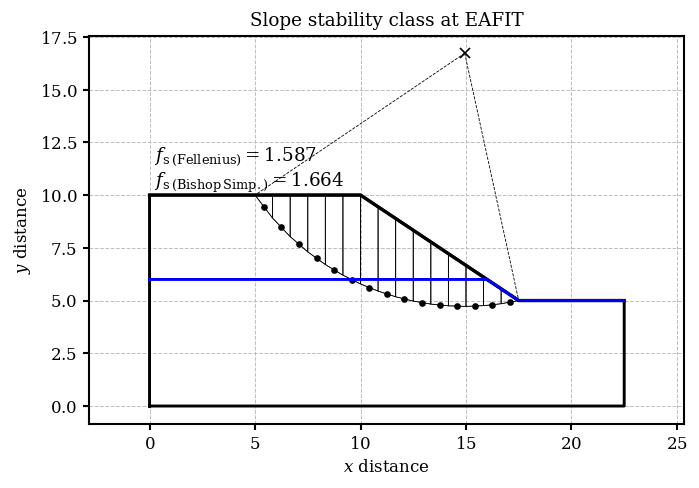

In [8]:
msg = get_fos(
    projectName,
    projectAuthor,
    projectDate,
    slopeHeight,
    slopeDip,
    crownDist,
    toeDist,
    wantAutomaticToeDepth,
    toeDepth,
    hztDistPointAtCrownFromCrown,
    hztDistPointAtToeFromCrown,
    slipRadius,
    wantWatertable,
    wtDepthAtCrown,
    toeUnderWatertable,
    waterUnitWeight,
    materialUnitWeight,
    frictionAngleGrad,
    cohesion,
    wantConstSliceWidthTrue,
    numSlices,
    nDivs,
    methodString,
    outputFormatImg
)
fig = plt.gcf()
# fig.set_size_inches(18.5, 10.5)

## Búsqueda del factor de seguridad mínimo entre múltiples superficies circulares $f_\mathrm{s}$

### Entradas adicionales para generar y evaluar superficies

In [9]:
numSlices = 15  # Number of discretizations of slip surface
numCircles = 500  # Number of surfaces to assess
radiusIncrement = [3, 'm']  # Length of radius increment
numberIncrements = 5  # Number of radius increment
maxFsValueCont = 3  # Mask to plot fs at screen

### Ejecución del análisis de estabilidad

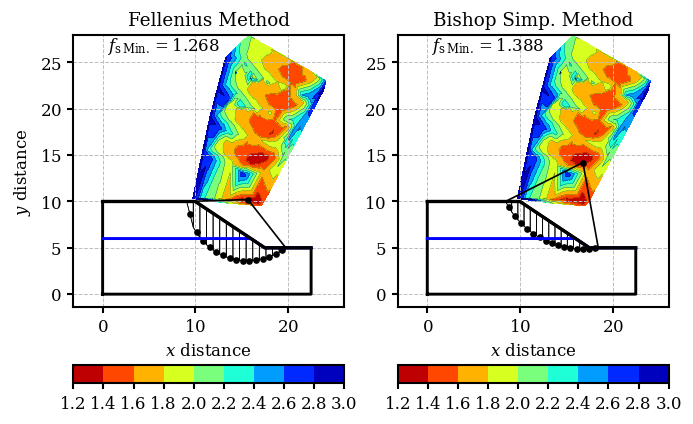

In [10]:
# %matplotlib inline 
get_min_fos(
    projectName,
    projectAuthor,
    projectDate,
    slopeHeight,
    slopeDip,
    crownDist,
    toeDist,
    wantAutomaticToeDepth,
    toeDepth,
    numCircles,
    radiusIncrement,
    numberIncrements,
    maxFsValueCont,
    wantWatertable,
    wtDepthAtCrown,
    toeUnderWatertable,
    waterUnitWeight,
    materialUnitWeight,
    frictionAngleGrad,
    cohesion,
    wantConstSliceWidthTrue,
    numSlices,
    nDivs,
    methodString,
    outputFormatImg,
)
fig = plt.gcf()
# fig.set_size_inches(18.5, 10.5)